In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import random

In [3]:
img = mpimg.imread("src/map_krikket.png")

## Visualisation de la carte
_____

In [4]:
img_centree = img * 255 - 93

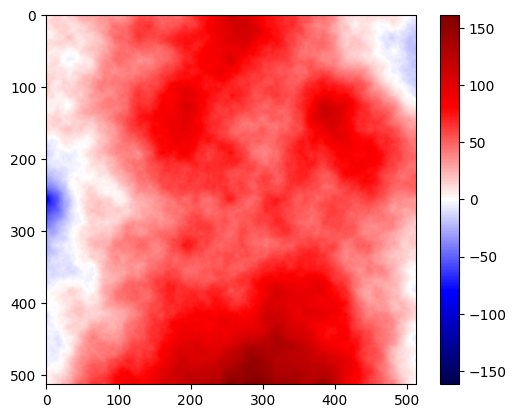

In [5]:
fig, ax = plt.subplots()
image = ax.imshow(img_centree, cmap="seismic", vmin=-162, vmax=162)
plt.colorbar(image, ax=ax)
plt.show()

## Fonctions
______

In [6]:
def check_border_limit(p1: tuple, img: np.ndarray) -> bool:
    """
    Fonction qui vérifie que les coordonnées du point ``p1`` sont bien dans le tableau ``img``.

    Args:
        p1 (tuple) : les coordonnées du point dont on souhaite vérifier qu'il est dans le tableau.
        img (numpy.ndarray) : le tableau.

    Returns:
        bool : True si p1 est dans img, False autrement.
    """
    if p1[0] > img.shape[0]-1 or p1[1] > img.shape[1]-1:
        return False
    return True

In [7]:
def compute_denivele_between_two_points(p1: tuple, p2: tuple, img: np.ndarray) -> float:
    """
    Fonction qui calcule le dénivelé entre les points ``p1`` et ``p2`` du tableau ``img``.

    Args:
        p1 (tuple) : les coordonnées du point p1.
        p2 (tuple) : les coordonnées du point p2.
        img (numpy.ndarray) : le tableau.
    """
    if not check_border_limit(p1, img) or not check_border_limit(p2, img):
        return False
    return float(img[p2[0]][p2[1]] - img[p1[0]][p1[1]])

In [73]:
def compute_denivele(path: list[tuple], img: np.ndarray) -> int:
    denivele = 0
    alt = [img[row][col] for row, col in path]

    for i in range(len(alt)-1):
        delta = alt[i+1] - alt[i]
        if delta > 0:
            denivele += delta

    return denivele

In [9]:
compute_denivele_between_two_points(p1, p2, img_centree)

0.0

In [10]:
img_centree.shape

(513, 513)

In [11]:
type(img_centree)

numpy.ndarray

In [12]:
def choice_direction_by_looking_n_forward(p1: tuple, img: np.ndarray, n: int):

    # On vérifie que le point courant est bien dans l'image (c'est censé être toujours le cas mais on vérifie quand même).
    if not check_border_limit(p1=p1, img=img):
        raise ValueError("Le point courant est hors de l'image.")

    n_col = img.shape[1]
    n_row = img.shape[0]
        

    # On vérifie si on est sur un bord:
    # - si on est sur la dernière colonne (tout à droite), on est obligé de descendre.
    # - si on est sur la dernière ligne (tout en bas), on est obligé d'aller à droite.
    # - si on est à la fois sur la dernière colonne ET la dernière ligne (sur le point B), on continue de retourner le point B.
    if p1[0] == n_row-1 and p1[1] == n_col-1:
        return p1
    elif p1[0] == n_row-1:
        return (p1[0], p1[1]+1)
    elif p1[1] == n_col-1:
        return (p1[0]+1, p1[1])

    # <--- Ajout suite au test 02 ----------------------------------->
    # On vérifie si on est sur l'avant dernière colonne
    # Dans ce cas là, si on va à droite, après on ne pourra plus que descendre.
    # On compare donc le dénivelé entre : la case du bas et la case maximale de la dernière colonne pour rejoindre le point B.
    if p1[0] == n_col-2:
        bottom_delivele = compute_denivele_between_two_points(p1=p1, p2=(p1[0]+1, p1[1]), img=img)
        max_alt = max(img[p1[0]:,n_col-1])
        right_delivele = max_alt - float(img[p1[0]][p1[1]])
        if bottom_delivele < right_delivele:
            return (p1[0]+1, p1[1])
        elif bottom_delivele >= right_delivele:
            return (p1[0], p1[1]+1)

    # On vérifie si on est sur l'avant dernière ligne
    # Dans ce cas là, si on va en bas, après on ne pourra plus que aller à droite.
    # On compare donc le dénivelé entre : la case de droite et la case maximale de la dernière ligne pour rejoindre le point B.
    if p1[1] == n_row-2:
        right_delineve = compute_denivele_between_two_points(p1=p1, p2=(p1[0], p1[1]+1), img=img)
        max_alt = max(img[n_row-1,p1[1]:])
        bottom_delivele = max_alt - float(img[p1[0]][p1[1]])
        if right_delineve < bottom_delivele:
            return (p1[0], p1[1]+1)
        elif right_delineve >= bottom_delivele:
            return (p1[0]+1, p1[1])
    # <---------------------------------------------------------------->

    # Pour pouvoir regarder n cases sur la droite, il faut qu'il y ait au moins n case à droite du point courant (idem vers le bas).
    if min(n_row - p1[0], n_col - p1[1]) < n:
        n = min(n_row - p1[0], n_col - p1[1])

    # =============================================
    # Calcul du gradient des n cases vers la droite
    # =============================================

    right_denivele = 0

    for i in range(1, n+1):
        delta = compute_denivele_between_two_points(p1=p1, p2=(p1[0], p1[1]+i), img=img)
        if delta > 0:
            right_denivele += delta

    # ==========================================
    # Calcul du gradient des n cases vers le bas
    # ==========================================

    bottom_denivele = 0

    for i in range(1, n+1):
        delta = compute_denivele_between_two_points(p1=p1, p2=(p1[0]+1, p1[1]), img=img)
        if delta > 0:
            bottom_denivele += delta

    # =================
    # Prise de décision
    # =================

    if right_denivele < bottom_denivele:
        return (p1[0], p1[1]+1)

    elif right_denivele > bottom_denivele:
        return (p1[0]+1, p1[1])

    # En cas d'égalité du gradient droite/bas, on prends une décision aléatoire.
    elif right_denivele == bottom_denivele:
        return random.choice([(p1[0], p1[1]+1), (p1[0]+1, p1[1])])


In [13]:
choice_direction_by_looking_n_forward(p1=(0,0), img=img_centree, n=1)

(1, 0)

### Test de la fonction de prise de décision
____

#### Test 01

In [136]:
img_test_01 = np.array([[100, 150, 255],[160, 255, 255], [120, 180, 100]])

In [137]:
position = (0,0)
path_n1 = []

for i in range(10):
    path_n1.append(position)
    position = choice_direction_by_looking_n_forward(p1=position, img=img_test_01, n=1)

In [138]:
position = (0,0)
path_n2 = []

for i in range(10):
    path_n2.append(position)
    position = choice_direction_by_looking_n_forward(p1=position, img=img_test_01, n=2)

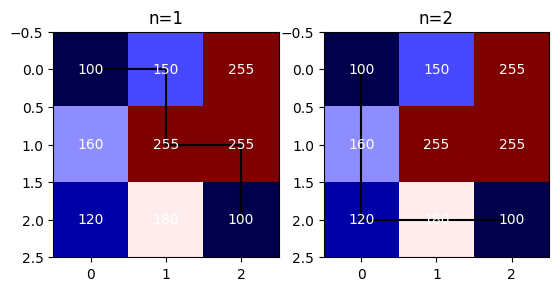

In [139]:
fig, ax = plt.subplots(nrows=1, ncols=2)
image = ax[0].imshow(img_test_01, cmap="seismic", vmin=100, vmax=255)
ax[0].plot([i[1] for i in path_n1], [i[0] for i in path_n1], color="k")
ax[0].set_title("n=1")

image = ax[1].imshow(img_test_01, cmap="seismic", vmin=100, vmax=255)
ax[1].plot([i[1] for i in path_n2], [i[0] for i in path_n2], color="k")
ax[1].set_title("n=2")

for i in range(len(path_n1[0])+1):
    for j in range(len(path_n1[1])+1):
        text = ax[0].text(j, i, img_test_01[i, j],
                       ha="center", va="center", color="w")
for i in range(len(path_n1[0])+1):
    for j in range(len(path_n1[1])+1):
        text = ax[1].text(j, i, img_test_01[i, j],
                       ha="center", va="center", color="w")

#plt.colorbar(image, ax=ax)

plt.show()

En regardant seulement 1 case devant soit, on préfère passer de 100 à 150 que de 100 à 160.
Pourtant, en partant sur le 150, on se retrouve "piégé" au milieu de 255.

En allant sur le 160 dès le début, on a un meilleur chemin, trouvé en regardant 2 cases devant soit à chaque décision au lieu de 1.

#### Test 02

In [141]:
img_test_02 = np.array([[130, 127],[154, 207], [100, 148]])

In [142]:
img_test_02

array([[130, 127],
       [154, 207],
       [100, 148]])

In [150]:
position = (0,0)
path_n1 = []

for i in range(10):
    path_n1.append(position)
    position = choice_direction_by_looking_n_forward(p1=position, img=img_test_02, n=1)

In [151]:
position = (0,0)
path_n2 = []

for i in range(10):
    path_n2.append(position)
    position = choice_direction_by_looking_n_forward(p1=position, img=img_test_02, n=2)

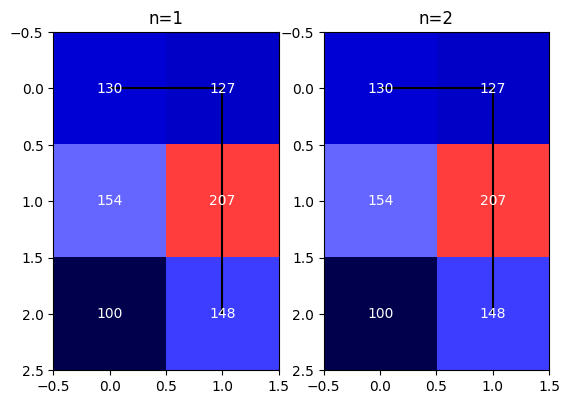

In [158]:
fig, ax = plt.subplots(nrows=1, ncols=2)
image = ax[0].imshow(img_test_02, cmap="seismic", vmin=100, vmax=255)
ax[0].plot([i[1] for i in path_n1], [i[0] for i in path_n1], color="k")
ax[0].set_title("n=1")

image = ax[1].imshow(img_test_02, cmap="seismic", vmin=100, vmax=255)
ax[1].plot([i[1] for i in path_n2], [i[0] for i in path_n2], color="k")
ax[1].set_title("n=2")

for i in range(len(path_n1[0])+1):
    for j in range(len(path_n1[1])):
        text = ax[0].text(j, i, img_test_02[i, j],
                       ha="center", va="center", color="w")
for i in range(len(path_n1[0])+1):
    for j in range(len(path_n1[1])):
        text = ax[1].text(j, i, img_test_02[i, j],
                       ha="center", va="center", color="w")

#plt.colorbar(image, ax=ax)

plt.show()

On voit que l'algorithme de prise de décision n'est pas efficace lorsque l'on arrive au bord.
En regardant 2 cases vers la droite, l'argo prends la décision de n'en regarder qu'une seule puisqu'il n'y en a pas 2 dispo.
Cela revient à avoir n=1.

Or, avec n=1 dans cette situation, on préfère partir à droite et on se retrouve "piégé" à devoir aller sur le 207.

Le problème est peut être qu'on ne prends pas en compte la case diagonale ?

#### Test 03

In [14]:
img_test_03 = np.array([[130, 127],[154, 207], [100, 148]])

In [16]:
position = (0,0)
path_n1 = []

for i in range(10):
    path_n1.append(position)
    position = choice_direction_by_looking_n_forward(p1=position, img=img_test_03, n=1)

In [18]:
position = (0,0)
path_n2 = []

for i in range(10):
    path_n2.append(position)
    position = choice_direction_by_looking_n_forward(p1=position, img=img_test_03, n=2)

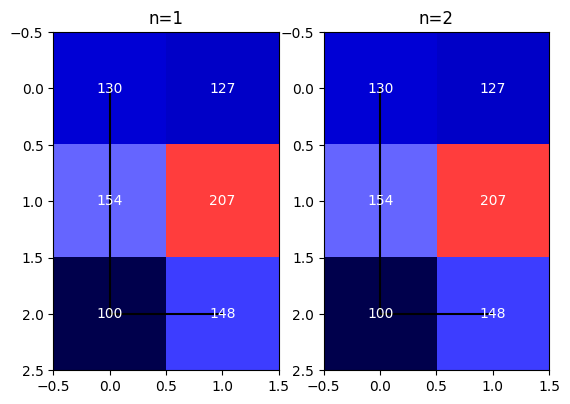

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=2)
image = ax[0].imshow(img_test_03, cmap="seismic", vmin=100, vmax=255)
ax[0].plot([i[1] for i in path_n1], [i[0] for i in path_n1], color="k")
ax[0].set_title("n=1")

image = ax[1].imshow(img_test_03, cmap="seismic", vmin=100, vmax=255)
ax[1].plot([i[1] for i in path_n2], [i[0] for i in path_n2], color="k")
ax[1].set_title("n=2")

for i in range(len(path_n1[0])+1):
    for j in range(len(path_n1[1])):
        text = ax[0].text(j, i, img_test_03[i, j],
                       ha="center", va="center", color="w")
for i in range(len(path_n1[0])+1):
    for j in range(len(path_n1[1])):
        text = ax[1].text(j, i, img_test_03[i, j],
                       ha="center", va="center", color="w")

#plt.colorbar(image, ax=ax)

plt.show()

Grâce au ajouts dans la fonction choice_direction_by_looking_n_forward() suite au test 02, la prise de décision prends maintenant en considération la fait que si on atteint un bord, après on est obligé de le longer, peut importer les dénivelés; ce qui peut être très gênant.
Ici, on voit bien que l'algorithme préfère passer de 130 à 154 (soit +24) au lieu de 130 à 127 (soit -3), car une fois sur la colonne de droite, on sera contraint de passer sur le 207.

## Test sur la carte complète
_____

In [63]:
position = (0, 0)
path_n1 = []

for i in range(1050):
    path_n1.append(position)
    position = choice_direction_by_looking_n_forward(p1=position, img=img_centree, n=1)

In [64]:
position = (0, 0)
path_n2 = []

for i in range(1050):
    path_n2.append(position)
    position = choice_direction_by_looking_n_forward(p1=position, img=img_centree, n=2)

In [65]:
position = (0, 0)
path_n3 = []

for i in range(1050):
    path_n3.append(position)
    position = choice_direction_by_looking_n_forward(p1=position, img=img_centree, n=3)

In [66]:
position = (0, 0)
path_n4 = []

for i in range(1050):
    path_n4.append(position)
    position = choice_direction_by_looking_n_forward(p1=position, img=img_centree, n=4)

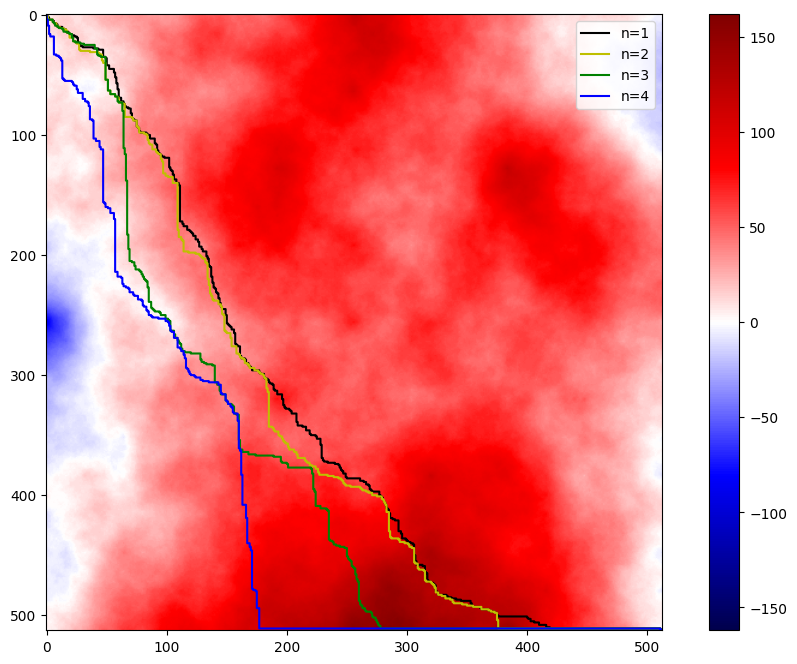

In [72]:
fig, ax = plt.subplots(figsize=(12,8))
image = ax.imshow(img_centree, cmap="seismic", vmin=-162, vmax=162)
plt.colorbar(image, ax=ax)
#ax.plot([i[0] for i in path], [i[1] for i in path], color="k")
ax.plot([i[1] for i in path_n1], [i[0] for i in path_n1], color="k", label="n=1")
ax.plot([i[1] for i in path_n2], [i[0] for i in path_n2], color="y", label="n=2")
ax.plot([i[1] for i in path_n3], [i[0] for i in path_n3], color="g", label="n=3")
ax.plot([i[1] for i in path_n4], [i[0] for i in path_n4], color="b", label="n=4")

plt.legend()

plt.show()

In [77]:
print(f"Avec n=1, le dénivelé total est : {compute_denivele(path=path_n1, img=img_centree)}")
print(f"Avec n=2, le dénivelé total est : {compute_denivele(path=path_n2, img=img_centree)}")
print(f"Avec n=3, le dénivelé total est : {compute_denivele(path=path_n3, img=img_centree)}")
print(f"Avec n=4, le dénivelé total est : {compute_denivele(path=path_n4, img=img_centree)}")

Avec n=1, le dénivelé total est : 323.0
Avec n=2, le dénivelé total est : 350.0
Avec n=3, le dénivelé total est : 361.0
Avec n=4, le dénivelé total est : 386.0
